# Fitting the theoretical risk curves

Fits the asymptotic theory to the empirical risk curves produced by
`risk_curves.ipynb` (default input: `ACE2_risk_landscape.csv`), and reproduces
the risk-curve figure of the paper.

**Model.** Under the independent-site sampling model with mutation probability
$f$, the covariance of the one-hot-encoded sequences has two nonzero
eigenvalues per site:

$$t_1 = \frac{qf(1-f)}{q-1} \;(\text{wild-type direction, multiplicity } L),
\qquad t_2 = \frac{f}{q-1} \;(\text{orthogonal complement, multiplicity } (q-2)L).$$

With $q$ and $f$ known, the asymptotic noisy-label test risk is **linear** in
three unknown combinations:

$$A = \|g^*\|^2 F,\qquad B = \|g^*\|^2 (1-F),\qquad s = R_0,$$

the aligned/orthogonal signal energies and the noise-plus-misspecification
floor. For training size $n = qL/r$ and ridge convention $X^TX + n\lambda\,\mathbb{I}$:

$$R(r,\lambda) = (1+v)\Big[s + \lambda^2 t_1 d_1^2\, A + \lambda^2 t_2 d_2^2\, B\Big],
\qquad d_\alpha = \frac{1}{\lambda + \kappa t_\alpha},$$

$$\kappa^{-1} = 1 + \frac{1}{n}\sum_\alpha \frac{m_\alpha t_\alpha}{\lambda + \kappa t_\alpha},
\qquad v = \frac{\gamma}{1-\gamma},
\quad \gamma = \frac{\kappa^2}{n}\sum_\alpha m_\alpha t_\alpha^2 d_\alpha^2 .$$

Useful endpoint checks: $R_{r\to0}(\lambda) = s + t_1 A \big(\frac{\lambda}{t_1+\lambda}\big)^2
+ t_2 B\big(\frac{\lambda}{t_2+\lambda}\big)^2$ and $R_{r\to\infty} = s + t_1A + t_2B$.

**Fit.** Nonnegative least squares over $(A, B, s)$ on all grid points (convex
objective, hence the global minimum), with weights $1/s_R^2$ where $s_R$ is the
**trial standard deviation** (a floor of $10^{-6}$ avoids overweighting
near-deterministic points). Error bars in the figure likewise show the trial
standard deviation.

Requirements: `numpy`, `pandas`, `scipy`, `matplotlib`.

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq, nnls

INPUT_CSV = Path('../data/ACE2_Wuhan_risk_landscape.csv')
OUTPUT_PDF = Path('../data/ACE2_risk_landscape_fit.pdf')

# experimental setup (fixed, not fitted)
q, L = 20, 201
f = 0.012852486748499694      # mutation probability, lambda_hat / L from the library

# fit settings
WEIGHTING = 'sd'              # 'sd': inverse-squared trial SD; 'uniform': no weights
SD_FLOOR = 1e-6
R_POINTS = 401                # theory-curve resolution in r

plt.rcParams.update({'axes.labelsize': 11, 'axes.labelweight': 'bold',
                     'xtick.labelsize': 11, 'ytick.labelsize': 11,
                     'legend.fontsize': 11})

## Theoretical risk

The self-consistency equation for $\kappa$ is monotone, so it is solved by
bisection (`brentq`).

In [2]:
t1 = q * f * (1 - f) / (q - 1)   # wild-type eigenvalue, multiplicity m1
t2 = f / (q - 1)                 # orthogonal eigenvalue, multiplicity m2
m1, m2 = L, (q - 2) * L

def risk_model(r, lam, A, B, s):
    """Asymptotic noisy-label test risk at aspect ratio r and ridge penalty lam."""
    n = q * L / r
    eq = lambda k: k * (1 + (m1 * t1 / (lam + k * t1)
                             + m2 * t2 / (lam + k * t2)) / n) - 1
    kappa = brentq(eq, 1e-15, 1.0, xtol=1e-14, rtol=1e-12)
    d1 = 1.0 / (lam + kappa * t1)
    d2 = 1.0 / (lam + kappa * t2)
    gamma = kappa**2 / n * (m1 * t1**2 * d1**2 + m2 * t2**2 * d2**2)
    v = gamma / (1 - gamma)
    return (1 + v) * (s + lam**2 * t1 * d1**2 * A + lam**2 * t2 * d2**2 * B)

def design_row(r, lam):
    """Coefficients of (A, B, s) in the linear risk model."""
    n = q * L / r
    eq = lambda k: k * (1 + (m1 * t1 / (lam + k * t1)
                             + m2 * t2 / (lam + k * t2)) / n) - 1
    kappa = brentq(eq, 1e-15, 1.0, xtol=1e-14, rtol=1e-12)
    d1 = 1.0 / (lam + kappa * t1)
    d2 = 1.0 / (lam + kappa * t2)
    gamma = kappa**2 / n * (m1 * t1**2 * d1**2 + m2 * t2**2 * d2**2)
    v = gamma / (1 - gamma)
    return [(1 + v) * lam**2 * t1 * d1**2,
            (1 + v) * lam**2 * t2 * d2**2,
            1 + v]

## Load data and fit

The risk is linear in $(A, B, s)$ with physical constraints $A, B, s \geq 0$,
so `scipy.optimize.nnls` on the weighted design matrix gives the global
minimum.

In [3]:
df = pd.read_csv(INPUT_CSV)
assert np.allclose(df['r'], q * L / df['M'], rtol=1e-5), 'r must equal q*L/M'

X = np.array([design_row(r, lam) for r, lam in zip(df['r'], df['mu'])])
y = df['R'].to_numpy()

if WEIGHTING == 'sd':
    w = 1.0 / np.maximum(df['sR'].to_numpy(), SD_FLOOR)**2
elif WEIGHTING == 'uniform':
    w = np.ones(len(df))
else:
    raise ValueError(f'Unknown weighting: {WEIGHTING}')

beta, _ = nnls(X * np.sqrt(w)[:, None], y * np.sqrt(w))
A, B, s = beta

G2 = A + B                    # squared norm of the binding vector
F = A / G2                    # wild-type aligned fraction
S = t1 * A + t2 * B           # total learnable signal
print(f'A = {A:.3f}   B = {B:.3f}   s = {s:.4f}')
print(f'||g*||^2 = {G2:.2f}   F = {F:.4f}')
print(f'R_0 = {s:.4f}   R_inf = {s + S:.4f}   S = R_inf - R_0 = {S:.4f}')
print(f'weighted RMSE = {np.sqrt(np.average((X @ beta - y)**2, weights=w)):.4f}')

A = 191.725   B = 522.004   s = 1.0782
||g*||^2 = 713.73   F = 0.2686
R_0 = 1.0782   R_inf = 3.9918   S = R_inf - R_0 = 2.9136
weighted RMSE = 0.0444


## Plot

Data points with error bars given by the **trial standard deviation** `sR`
(for the standard error of the mean use `sR / np.sqrt(nTrial)` instead).
Solid lines: fitted theoretical prediction on `R_POINTS` log-spaced values
of $r$.

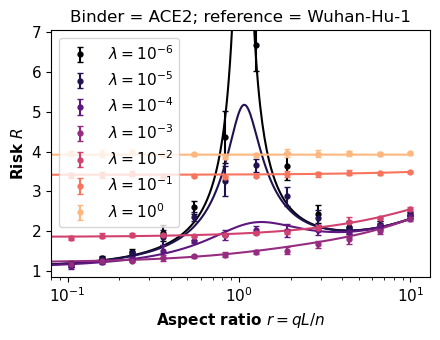

In [4]:
lams = sorted(df['mu'].unique())
colors = plt.cm.magma(np.linspace(0, 0.85, len(lams)))
r_fine = np.logspace(np.log10(df['r'].min()), np.log10(df['r'].max()), R_POINTS)

fig, ax = plt.subplots(figsize=(4.5, 3.5))
for lam, c in zip(lams, colors):
    sub = df[np.isclose(df['mu'], lam)].sort_values('r')
    ax.errorbar(sub['r'], sub['R'], yerr=sub['sR'], fmt='o', ms=3.5,
                capsize=2, color=c, label=f'$\\lambda = 10^{{{int(np.log10(lam))}}}$')
    ax.plot(r_fine, [risk_model(r, lam, A, B, s) for r in r_fine], color=c)

ax.set_xscale('log')
ax.set_xlim(0.08, 13)
ax.set_ylim(0.85, 7.05)
ax.set_xlabel('Aspect ratio $r = qL/n$')
ax.set_ylabel('Risk $R$')
ax.set_title('Binder = ACE2; reference = Wuhan-Hu-1')
ax.legend()
fig.tight_layout()
plt.show()

In [7]:
fig.savefig(OUTPUT_PDF, format='pdf', bbox_inches='tight')
print(f'Saved {OUTPUT_PDF.resolve()}')

Saved /home/alessandro/Desktop/ENS/dms_python_migration/AISTATS_2027/reproducibility/data/ACE2_risk_landscape_fit.pdf
